In [12]:
import pandas as pd
import numpy as np

# Load original dataset
df = pd.read_csv("Real_Estate_Sales_10012020_to_Current.csv")
df.head()

,OBJECTID,PropertyID,xrCompositeLandUseID,xrBuildingTypeID,ParcelID,LocationStartNumber,ApartmentUnitNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,...,OwnerFirstName,PrimaryGrantor,SaleDate,SalePrice,TotalAppraisedValue,LegalReference,xrSalesValidityID,xrDeedID,AssrLandUse,GlobalID
0,1,8,3,6.0,121-698-063,77,NaN,STAFFORD ST,2,6000.0,...,LAKESHA,SCOTT NASTASSIA,2024/07/01 00:00:00+00,259000.0,187200,08275 0343,1,10,ONE FAMILY,{78B6AAB5-D21E-471C-85BE-022DAB2A80B7}
1,2,9,3,3.0,121-698-062,73,NaN,STAFFORD ST,2,6000.0,...,ARCADIO,DIAZ RAFAEL,2022/04/26 00:00:00+00,208000.0,192300,07948-0001,1,10,ONE FAMILY,{15F34650-E463-4047-8808-A056FCDA3E09}
2,3,12,3,6.0,144-698-066,61,NaN,STAFFORD ST,2,6000.0,...,CATIRIA,KERN THOMAS,2023/12/22 00:00:00+00,125000.0,148400,08197-0077,1,10,ONE FAMILY,{C6FCA409-022A-4F1B-A674-13996FD1FE86}
3,4,20,3,6.0,144-698-058,29,NaN,STAFFORD ST,2,6000.0,...,REBECA,RAMOS MIGUEL JR,2023/09/29 00:00:00+00,1.0,167300,08158 0179,5,8,ONE FAMILY,{4D1DDED3-EF58-4091-A5F1-C7CA38B38C74}
4,5,25,3,6.0,144-698-053,211,NaN,NEWINGTON AVE,2,5040.0,...,LOURDES,BAIJANATH BISSNOW P,2021/01/11 00:00:00+00,177000.0,197900,07701-0245,1,10,ONE FAMILY,{F2E9A7CC-96D2-47AE-A2C1-59745FBE9C9E}


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7410 entries, 0 to 7409
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   OBJECTID                 7410 non-null   int64  
 1   PropertyID               7410 non-null   int64  
 2   xrCompositeLandUseID     7410 non-null   int64  
 3   xrBuildingTypeID         7409 non-null   float64
 4   ParcelID                 7410 non-null   object 
 5   LocationStartNumber      7410 non-null   int64  
 6   ApartmentUnitNumber      1938 non-null   object 
 7   StreetNameAndWay         7410 non-null   object 
 8   xrPrimaryNeighborhoodID  7410 non-null   int64  
 9   LandSF                   5479 non-null   float64
 10  TotalFinishedArea        7237 non-null   float64
 11  LivingUnits              7409 non-null   float64
 12  OwnerLastName            7410 non-null   object 
 13  OwnerFirstName           4515 non-null   object 
 14  PrimaryGrantor          

In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

ApartmentUnitNumber    5472
OwnerFirstName         2895
LandSF                 1931
SalePrice               339
TotalFinishedArea       173
xrBuildingTypeID          1
LivingUnits               1
PrimaryGrantor            1
LegalReference            1
dtype: int64

In [18]:
#Too many missing. Not important for price analysis.
df = df.drop(columns=["ApartmentUnitNumber"])


In [20]:
#Owner name is not useful for business analytics.
df = df.drop(columns=["OwnerFirstName"])

In [22]:
#Price is critical.
df = df.dropna(subset=["SalePrice"])

In [24]:
#Important variable → fill with median.
df["LandSF"] = df["LandSF"].fillna(df["LandSF"].median())

In [26]:
#Handle TotalFinishedArea
df["TotalFinishedArea"] = df["TotalFinishedArea"].fillna(df["TotalFinishedArea"].median())

In [28]:
#now checkingg for missing values again
df.isnull().sum().sum()

4

In [30]:
df["LandSF"] = df["LandSF"].fillna(df["LandSF"].median())
df["LandSF"].isnull().sum()

0

In [32]:
#completely handles misssing values

In [34]:
# Check how many duplicate rows exist
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [36]:
# Basic statistics of SalePrice
df["SalePrice"].describe()

count    7.071000e+03
mean     8.283798e+05
std      4.176929e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.300000e+05
75%      2.700000e+05
max      6.050000e+07
Name: SalePrice, dtype: float64

In [38]:
# Count how many SalePrice values are 0
zero_price_count = (df["SalePrice"] == 0).sum()
print("Number of zero SalePrice rows:", zero_price_count)

Number of zero SalePrice rows: 1930


In [40]:
'''
SalePrice = 0 usually means

Property transfer within family

Government transfer

Correction entry

Missing price recorded as 0
'''

'\nSalePrice = 0 usually means\n\nProperty transfer within family\n\nGovernment transfer\n\nCorrection entry\n\nMissing price recorded as 0\n'

In [42]:
# Create a flag for zero-price transactions
df["WasZeroPrice"] = df["SalePrice"] == 0

In [44]:
df.to_csv("dataset_with_zero_flag.csv", index=False)

In [46]:
#Create Market Dataset (Remove Zero Prices)
market_df = df[df["SalePrice"] > 0].copy()

In [52]:
'''so we have moved to dataset market_df for working further because we want to preserve prices==0, 
as it provides insights about property given as gift, free etc'''

'so we have moved to dataset market_df for working further because we want to preserve prices==0, \nas it provides insights about property given as gift, free etc'

In [55]:
# Check distribution
market_df["SalePrice"].describe()

count    5.141000e+03
mean     1.139365e+06
std      4.862443e+06
min      1.000000e+00
25%      1.000000e+05
50%      2.150000e+05
75%      3.160000e+05
max      6.050000e+07
Name: SalePrice, dtype: float64

In [57]:
# Calculate 99th percentile threshold
upper_limit = market_df["SalePrice"].quantile(0.99)

print("99th percentile value:", upper_limit)

99th percentile value: 10250144.0


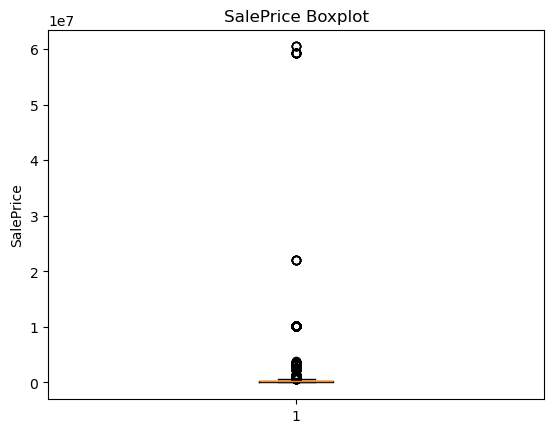

In [59]:
# Boxplot to visually inspect extreme outliers
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(market_df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.ylabel("SalePrice")
plt.show()

In [61]:
# Remove extreme top 1% outliers
market_df = market_df[market_df["SalePrice"] <= upper_limit]

print("Rows after removing outliers:", market_df.shape[0])

Rows after removing outliers: 5107


In [63]:
# Check distribution after removing top 1% outliers
market_df["SalePrice"].describe()

count    5.107000e+03
mean     8.024572e+05
std      2.260076e+06
min      1.000000e+00
25%      9.750000e+04
50%      2.130000e+05
75%      3.150000e+05
max      1.025014e+07
Name: SalePrice, dtype: float64

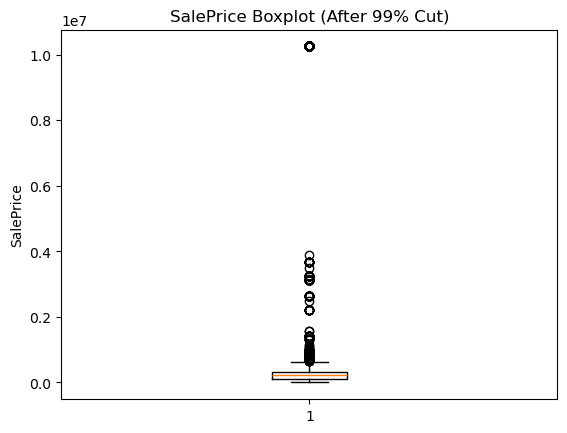

In [65]:
# Boxplot after removing top 1%
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(market_df["SalePrice"])
plt.title("SalePrice Boxplot (After 99% Cut)")
plt.ylabel("SalePrice")
plt.show()

In [ ]:
'''Clear observation:

Box is STILL compressed.

Many large values above 1M.

Market is naturally skewed (real estate always is).

Now we do NOT remove more.

Next correct move:

🔹 Use Log Scale Visualization (instead of deleting more data)'''

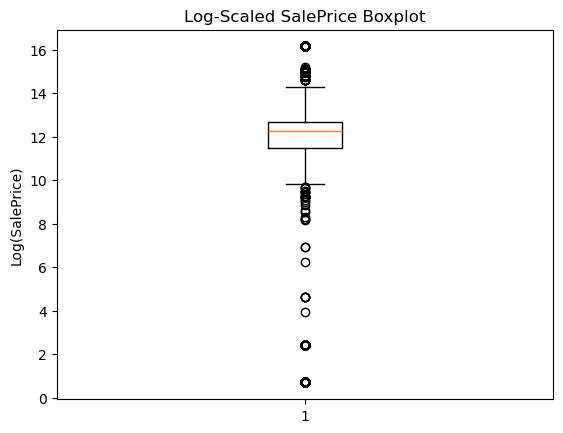

In [67]:
# Log transformation for better visualization
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(np.log1p(market_df["SalePrice"]))
plt.title("Log-Scaled SalePrice Boxplot")
plt.ylabel("Log(SalePrice)")
plt.show()

In [ ]:
'''The box is now properly visible.

Distribution looks much more balanced.

Skew is controlled.

No extreme distortion.

This means:

👉 We STOP removing data.
👉 We use log scale for analysis when needed.'''

In [69]:
# Create log-transformed SalePrice column for modeling & visualization
market_df["LogSalePrice"] = np.log1p(market_df["SalePrice"])

market_df[["SalePrice", "LogSalePrice"]].head()

,SalePrice,LogSalePrice
0,259000.0,12.464587
1,208000.0,12.245298
2,125000.0,11.736077
3,1.0,0.693147
4,177000.0,12.083911


In [ ]:
'''Now small but important observation:

You still have a row where SalePrice = 1.

That is not a real market sale.

We removed 0 earlier, but 1 is also basically a placeholder / symbolic transfer.

So next single step:

🔹 Remove SalePrice ≤ 1'''

In [71]:
# Remove symbolic / invalid very low prices
market_df = market_df[market_df["SalePrice"] > 1]

print("Rows after removing price = 1:", market_df.shape[0])

Rows after removing price = 1: 4568


In [73]:
# Recreate log column after removing price <= 1
market_df["LogSalePrice"] = np.log1p(market_df["SalePrice"])

market_df["SalePrice"].describe()


count    4.568000e+03
mean     8.971428e+05
std      2.371881e+06
min      1.000000e+01
25%      1.400000e+05
50%      2.300000e+05
75%      3.270000e+05
max      1.025014e+07
Name: SalePrice, dtype: float64

In [ ]:
'''Now:

Count = 4568 ✅

Min = 10 ✅ (realistic)

Median = 230,000 ✅

Max = 10,250,144 (acceptable high-end property)

Dataset is now clean and stable.

We stop cleaning here.'''

In [75]:
len(market_df.columns)

23

In [87]:
# Check if GlobalID is unique
market_df["OBJECTID"].nunique(), len(market_df)

(4568, 4568)

In [89]:
# Check if GlobalID is unique
market_df["GlobalID"].nunique(), len(market_df)

(4568, 4568)

In [91]:
#its understood that only global_id and object_id are unique 

In [101]:
# Drop only GlobalID (pure system identifier, no insight can be taken from this)
market_df = market_df.drop(columns=["GlobalID"])

print("GlobalID dropped.")
print("Current columns:")
print(market_df.columns)

GlobalID dropped.
Current columns:
Index(['OBJECTID', 'PropertyID', 'xrCompositeLandUseID', 'xrBuildingTypeID',
       'ParcelID', 'LocationStartNumber', 'StreetNameAndWay',
       'xrPrimaryNeighborhoodID', 'LandSF', 'TotalFinishedArea', 'LivingUnits',
       'OwnerLastName', 'PrimaryGrantor', 'SaleDate', 'SalePrice',
       'TotalAppraisedValue', 'LegalReference', 'xrSalesValidityID',
       'xrDeedID', 'AssrLandUse', 'WasZeroPrice', 'LogSalePrice'],
      dtype='object')


In [103]:
market_df.to_csv("final_clean_market_dataset1.csv", index=False)